In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
def radial_area_split(inner_radius, outer_radius,
                      num_teeth, ele_area):
    """
    返回径向等分后的 r_list，使每个扇形环带面积大致等于 ele_area。
    """
    # 有效内外半径（排除齿根和齿顶扰动）
    R_in = inner_radius
    R_out = outer_radius
    # 总圆环面积
    ring_area = np.pi * (R_out**2 - R_in**2)
    # 单个齿对应的扇形面积（等于周向 30 等分）
    sector_area = ring_area / num_teeth
    # 径向等分层数
    N_r = int(np.round(sector_area / ele_area))
    N_r = max(N_r, 1)
    # 单层面积
    dA = sector_area / N_r
    # 扇形角度
    theta = 2 * np.pi / num_teeth
    # 径向分界半径
    r_list = [R_in]
    r0_squared = R_in**2
    for i in range(1, N_r + 1):
        r_i = np.sqrt(r0_squared + i * (2 * dA / theta))
        r_list.append(r_i)
    return np.array(r_list), N_r, ring_area, sector_area

size = (1280, 1280)
cx, cy = (640, 640)
inner_radius = 330
outer_radius = 600
ele_area = 61*61
num_teeth = 30
r_list, N_r, ring_area, sector_area = radial_area_split(
    inner_radius, outer_radius, num_teeth, ele_area
)

theta_list = np.linspace(0, 2 * np.pi, num_teeth * 2 + 1)

In [11]:
# 初始化全局变量
geom = []  # 节点坐标
connec = []  # 单元连接关系
nnd = 0  # 全局节点计数器
k = 0  # 全局单元计数器

inner_teeh_idx = []  # 内齿单元索引
outer_teeh_idx = []  # 外齿单元索引

NRE = len(r_list) - 1
NTE = len(theta_list) - 1

# 局部函数：检查并创建节点
def check_and_create_node(r, theta, tol=1e-6):
    global nnd, geom
    # 角度归一化到 [0, 2π)
    theta = theta % (2 * np.pi)
    for nn, (gr, gtheta) in enumerate(geom, start=1):
        # 归一化已有节点角度
        gtheta_norm = gtheta % (2 * np.pi)
        if np.isclose(r, gr, atol=tol) and np.isclose(theta, gtheta_norm, atol=tol):
            return nn  # 节点已存在
    # 节点不存在，创建新节点
    nnd += 1
    geom.append([r, theta])
    return nnd

# 计算节点和单元连接
for i in range(NRE):
    for j in range(NTE):
        k += 1  # 单元计数器
        
        # 节点编号规则
        r1 = r_list[i]          # 当前单元的内半径
        r2 = r_list[i + 1]      # 当前单元的外半径
        r_mid = (r1 + r2)/2     # 当前单元的中半径
        theta1 = theta_list[j]              # 当前单元的起始角度
        theta2 = theta_list[j + 1]          # 当前单元的结束角度
        theta_mid = (theta1 + theta2) / 2   # 圆弧的中间角度
        
        # 检查并创建节点 逆时针创建
        # 创建Q8单元的4个角点
        n1 = check_and_create_node(r1, theta1)
        n3 = check_and_create_node(r2, theta1)
        n5 = check_and_create_node(r2, theta2)
        n7 = check_and_create_node(r1, theta2)
        # 创建Q8单元的4个中间点
        n2 = check_and_create_node(r_mid, theta1)
        n4 = check_and_create_node(r2, theta_mid)
        n6 = check_and_create_node(r_mid, theta2)
        n8 = check_and_create_node(r1, theta_mid)
        # 生成单元连接关系
        connec.append([n1, n2, n3, n4, n5, n6, n7, n8])
        
# 输出结果检查
print(f'总节点数: {nnd}')
print(f'总单元数: {k}')

# 节点和单元文件写入
node_file = 'nodes.txt'  # 节点文件
element_file = 'elements.txt'  # 单元文件

# 写入节点文件
with open(node_file, 'w') as fid_nodes:
    for i, (r, theta) in enumerate(geom, start=1):
        x = r*np.cos(theta)+cx; y = r*np.sin(theta)+cy
        fid_nodes.write(f'{i}, {x:.6f}, {y:.6f}\n')
        
# 写入单元文件
with open(element_file, 'w') as fid_elements:
    for i, conn in enumerate(connec, start=1):
        conn = [conn[idx - 1] for idx in [1, 3, 5, 7, 2, 4, 6, 8]]
        fid_elements.write(f'{i}, ' + ', '.join(map(str, conn)) + '\n')
        
print('节点和单元文件已成功生成: nodes.txt 和 elements.txt')

总节点数: 1380
总单元数: 420
节点和单元文件已成功生成: nodes.txt 和 elements.txt


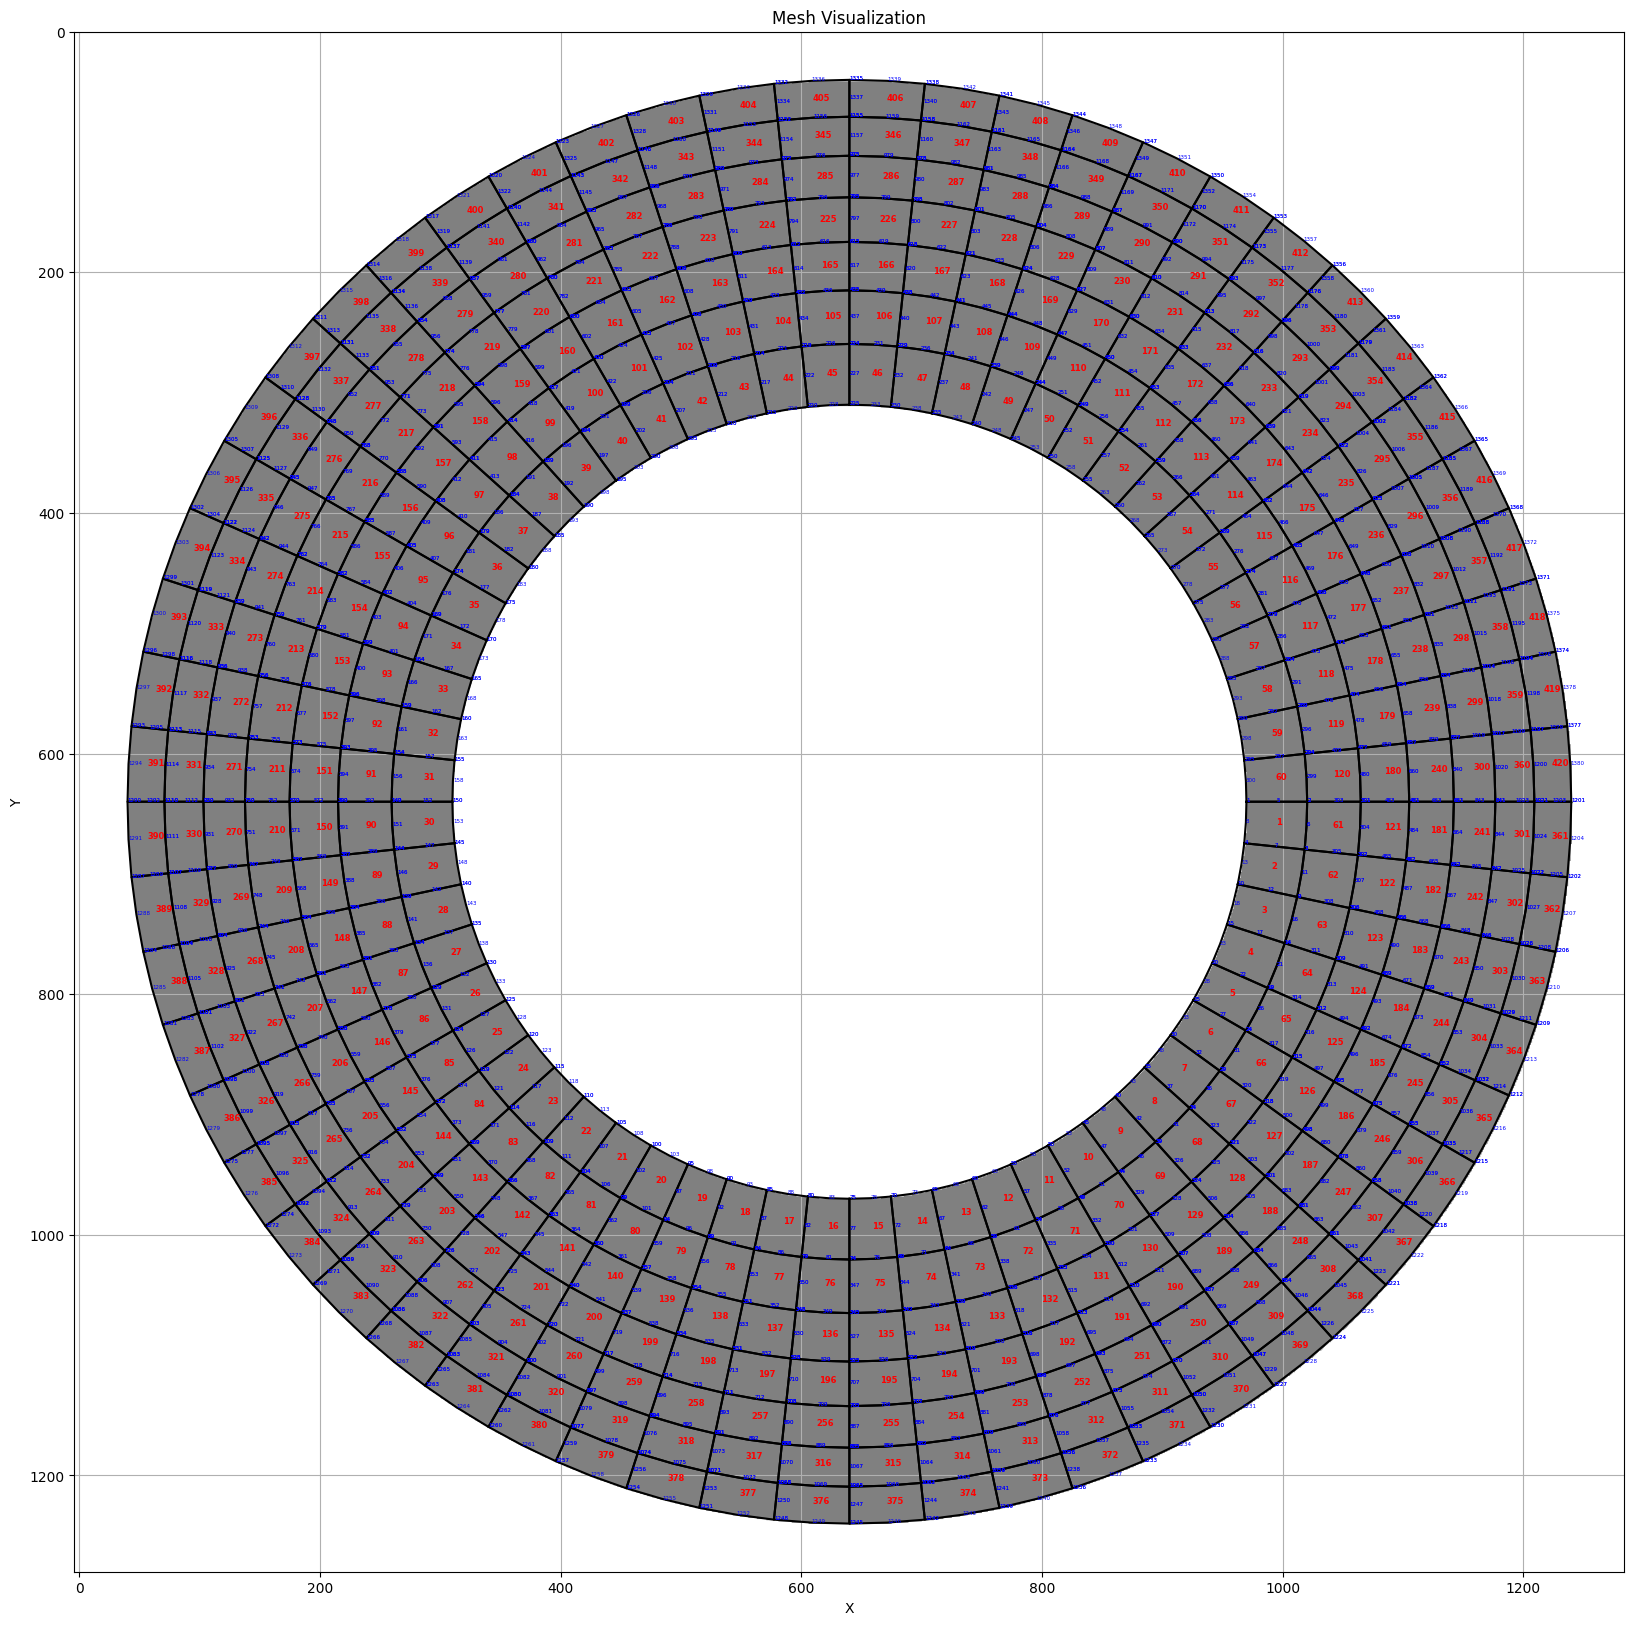

In [12]:
def read_nodes(node_file):
    node_ids = []
    coords = []
    with open(node_file, "r") as f:
        for line in f:
            parts = line.strip().split(",")
            nid = int(parts[0])
            x = float(parts[1])
            y = float(parts[2])
            node_ids.append(nid)
            coords.append([x, y])
    node_ids = np.array(node_ids)
    coords = np.array(coords)
    # 建立 node_id → 索引 的映射
    id2idx = {nid: i for i, nid in enumerate(node_ids)}
    return coords, id2idx


def read_elements(elem_file):
    elements = []
    with open(elem_file, "r") as f:
        for line in f:
            parts = line.strip().split(",")
            # 跳过第一个 elem_id
            conn = [int(v) for v in parts[1:]]
            elements.append(conn)
    return elements

coords, id2idx = read_nodes("nodes.txt")
elements = read_elements("elements.txt")
# 读取原始齿轮图像作为背景
background_path = '002.bmp'
try:
    img = cv2.imread(background_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
except FileNotFoundError:
    # 若图像读取失败，创建白底图像用于测试
    img_rgb = np.ones((1280, 1280, 3), dtype=np.uint8) * 255

circle_roi = img > 0

fig, ax = plt.subplots(figsize=(20, 20))
ax.set_aspect("equal")
H, W = circle_roi.shape
ax.imshow(
        circle_roi,  
        extent=[0, W, H, 0],  # 定义坐标范围（假设 plot_validpoints 是 [0, W] x [0, H]）
        origin="upper",      # 图像原点在左下
        cmap="binary",       # 黑白背景
        alpha=0.5            # 半透明
    )
quad9_order0based = [0, 4, 1, 5, 2, 6, 3, 7] # 单元逆时针顺序
# 显示节点编号
for eid, conn in enumerate(elements, start=1):
    # 获取当前单元所有节点坐标
    pts = np.array([coords[id2idx[nid]] for nid in conn])
    pts_reordered  = pts[quad9_order0based]
    # 闭合 polygon
    pts_closed   = np.vstack([pts_reordered, pts_reordered[0]])
    # 画出单元边界
    plt.plot(pts_closed[:, 0], pts_closed[:, 1], '-k')
    for nid in conn:
        x, y = coords[id2idx[nid]]
        plt.text(x, y, str(nid), color='blue', fontsize=4)
    # 显示单元编号
    center_x = np.mean(pts[:,0])
    center_y = np.mean(pts[:,1])
    plt.text(center_x, center_y, str(eid), fontsize=6, color='red', fontweight='bold')
plt.axis("equal")
plt.xlabel("X")
plt.ylabel("Y")
# plt.gca().invert_yaxis()
plt.title("Mesh Visualization")
plt.grid(True)

In [13]:
def get_integer_points_of_RingElement(nodes, center, mask):
    """
    输入: nodes 为一个 8x2 矩阵, 表示单元的8个节点坐标 (x, y)
    输出：返回一个 Nx2 矩阵，包含所有整数坐标点
    8个节点的顺序为:
    逆时针方向: 首先4个角点, 其次四个中间点
    """
    # 提取节点的 x 和 y 坐标
    x_coords = nodes[:, 0]
    y_coords = nodes[:, 1]
    center_x, center_y = center

    # 计算内外半径
    r1 = np.min(np.sqrt((x_coords[:4] - center_x)**2 + (y_coords[:4] - center_y)**2))  # 内半径
    r2 = np.max(np.sqrt((x_coords[:4] - center_x)**2 + (y_coords[:4] - center_y)**2))  # 外半径
    # 计算左右边界角度
    angle_nodes = np.arctan2(y_coords[:4] - center_y, x_coords[:4] - center_x)  # 计算每个节点的角度
    # 将角度转换到 [0, 2*pi] 范围内
    flag_2pi = True
    angle_nodes_2pi = angle_nodes % (2 * np.pi) 
    theta1 = np.min(angle_nodes_2pi)
    theta2 = np.max(angle_nodes_2pi)
    if theta2-theta1 > np.pi:
        flag_2pi = False
        theta1 = np.min(angle_nodes)
        theta2 = np.max(angle_nodes)

    # 确定单元的最小和最大 x，y 坐标范围
    min_x = np.floor(np.min(x_coords))
    max_x = np.ceil(np.max(x_coords))
    min_y = np.floor(np.min(y_coords))
    max_y = np.ceil(np.max(y_coords))
    # print(min_x,max_x,min_y,max_y)

    # 生成单元内的网格（通过网格化 x 和 y 方向的坐标）
    mask_seg = mask[int(min_y):int(max_y+1), int(min_x):int(max_x+1)]
    mask_points = mask_seg.ravel()
    x_grid, y_grid = np.meshgrid(np.arange(min_x, max_x + 1), np.arange(min_y, max_y + 1))
    grid_points = np.vstack((x_grid.ravel(), y_grid.ravel())).T  # 转换为 Nx2 矩阵
    radius = np.sqrt((grid_points[:, 0] - center_x)**2 + (grid_points[:, 1] - center_y)**2)  # 计算每个点到圆心的距离
    angles = np.arctan2(grid_points[:, 1] - center_y, grid_points[:, 0] - center_x)  # 计算每个点的角度
    if flag_2pi:
        angles = angles % (2 * np.pi)
    else:
        pass
    
    # 过滤出在圆环内的整数点
    radiu_points = np.logical_and(radius >= r1, radius <= r2, )  # 在圆环内的点
    angle_valid = np.logical_and(angles >= theta1, angles <= theta2)  # 在角度范围内的点
    valid_points = radiu_points & angle_valid & mask_points
    integer_points = grid_points[valid_points]  # 获取符合条件的整数点坐标
    return np.array(integer_points)


In [14]:
element_num = len(elements)
node_num = len(coords)

# 用于存储像素点和单元的关系
Inform = []
for eid, conn in enumerate(elements, start=1):
    # 获取当前单元所有节点坐标
    pts = np.array([coords[id2idx[nid]] for nid in conn])
    integer_points = get_integer_points_of_RingElement(pts, (cx,cy), circle_roi)
    for point in integer_points:
            Inform.append([point[0], point[1], eid])  # 注意单元编号从1开始
# 将 Inform 转换为 NumPy 数组
Inform = np.array(Inform)
# 保存 Inform 到 .npy 文件
np.save('Inform.npy', Inform) 


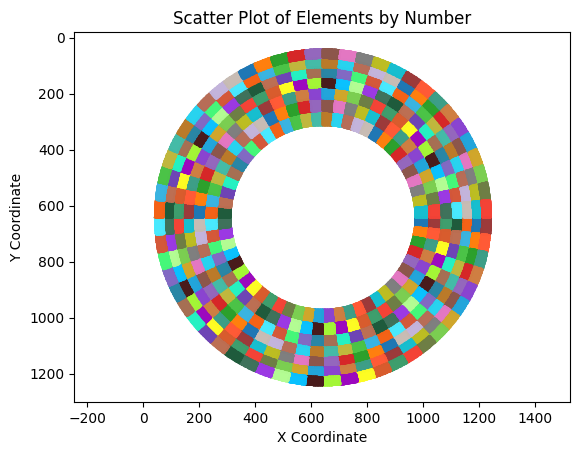

In [15]:
# 加载数据
Inform = np.load('Inform.npy')  # 读取 .npy 文件

# 初始化一个列表来存储不同编号的元素
numElements = int(np.max(Inform[:, 2]))  # 找到最大的单元编号
elements = [[] for _ in range(numElements)]  # 初始化一个空的列表，大小为 numElements

# 遍历 Inform 数组，将元素按编号存储到列表中
for row in Inform:
    num = int(row[2])  # 获取当前元素的编号
    elements[num - 1].append(row[:2])  # 存储元素（注意：这里我们也将编号存储了，以便后续使用）

fixed_colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#9c3a3a", "#ff5a36", "#3d9e87", "#cf7e42", "#8a44d0", "#22a5db", "#d0a62b", "#7bce51", "#6e7e45", "#f44336",
    "#3e9e6d", "#d85c2d", "#fdfc23", "#9c09be", "#a3f636", "#491b1b", "#0ac1fe", "#b3fc93", "#9b39e3", "#3f725b",
    "#1f5b3c", "#bc6f53", "#6e44b5", "#25f1c2", "#a66f53", "#2986a5", "#8269c3", "#45f779", "#d45839", "#49e9fe",
    "#f46216", "#3ab4e1", "#4bc347", "#c0b73d", "#44bba7", "#bb7a29", "#28d3ef", "#b76d57", "#c3b4db", "#c8bcb4"
]

# 绘制散点图
plt.figure()
colors = plt.cm.viridis(np.linspace(0, 1, numElements))  # 获取一个颜色数组，用于不同编号的元素
for num in range(numElements):
    if len(elements[num]) > 0:  # 检查该编号的元素是否存在
        elements_num = np.array(elements[num])  # 转换为 NumPy 数组
        color_idx = num % len(fixed_colors)
        plt.scatter(elements_num[:, 0], elements_num[:, 1], s=0.1, c=[fixed_colors[color_idx]], label=f'Element {num + 1}')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Scatter Plot of Elements by Number')
plt.xlim(0,1280); plt.ylim(1280,0)
plt.axis('equal')  # 确保坐标轴比例一致
plt.savefig('elements_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()